# EDA

**1. Расспишу вводные данные кейса: выдать или не выдать кредит клиенту**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

Пропишу основные данные о дефолте, прибыли и убытках. Тут же поясняю формулу и как я нашла порог одобрения / не одобрения кредита.

In [2]:
warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
RANDOM_STATE = 42

PROFIT_NONDF = 0.18   
LOSS_DF = 0.75    

PD_THRESHOLD  = PROFIT_NONDF / (PROFIT_NONDF + LOSS_DF)

print(f"Порог одобрения кредита: {PD_THRESHOLD :.5f}")
print(f"Выдаем кредит, когда модель предсказывает у клиента PD ниже {PD_THRESHOLD :.2%}")

Порог одобрения кредита: 0.19355
Выдаем кредит, когда модель предсказывает у клиента PD ниже 19.35%


Всё из условия нашего кейса: если мы одобрили клиента и он не ушёл в дефолт, мы заработали 18 % от его лимита. Если одобрили и он ушёл в дефолт, мы потеряли 75 % лимита. 

Для простоты вероятность дефолта обозначу за общепринятую p, а лимит клиента будет L (в условии это desired_credit_limit). Ещё заранее обусловлюсь, что лимит всегда положительное число.

Если мы одобряем кредит, то получается есть всего 2 исхода: Клиент не ушёл в дефолт, получаем 0.18 * L (из условия desired_credit_limit\*18%). Или клиент ушёл в дефолт, и мы получаем - 0.75 * L (тоже по условию desired_credit_limit\*75%, и минус, так как это убыток)

Расспишем ожидаемый результат в виде формулы:

Конечная формула это сумма исходов, каждый из которых умножен на вероятность своего наступления:

Прибыль = (1 - p) * (0.18 * L)  +  p * (-0.75 * L)

(1 - p) думаю очевидно, это противоположное событие, вероятность, что дефолт не наступил. Кредит вернут. Её ещё любят за q обозначать.

(0.18 * L) - благоприятный результат, заработаем

p * (-0.75 * L) - неблагоприятный результат, понесли убытки

Преобразуем формулу и получится, что выносим L за скобки (0.18 - 0.93 * p) > 0. 

Ещё важно обозначить, что клиент, ушедший в дефолт, не только забирает 0.75 лимита, но ещё и не приносит те 0.18, которые принёс бы, вернув кредит. То есть мы как банк не только не теряем с дефолта, но ещё и не зарабатываем 18 %, так как нам не вернули кредит. Поэтому складываем 0.18 + 0.75 = 0.93 и на это число умножаем вероятность дефолта.

Можно проинтерпретировать как: каждый дополнительный % вероятности дефолта стоит 0.93 от лимита.

Далее при делении неравенства на положительное число (L - наш лимит) знак неравенства не меняется, поэтому поделим обе стороны на L. Получается 0.18 - 0.93 * p > 0, 0.18 > 0.93 * p, p < 0.18 / 0.93, итого примерно p < 0.19355, это число будет нашим порогом для выдачи или если число выше для не выдачи кредита. 


**2. Загружи наши данные, чтобы получше посмотреть на них.**

In [3]:
path_to_data = "historical_data.csv"
OOT_path = "OOT.csv"
TARGET = "default_within_1y"

def load_data(path):
    return pd.read_csv(path, keep_default_na=False, na_values=[""])

df = load_data(path_to_data)

print("Размер обучающей выборки:", df.shape)
print(f"Доля дефолтов в нашей выборке = {df[TARGET].mean():.4f}")
print()

edu = df["education"].fillna("(пустая строка это точно пропуск)")
print(df.groupby(edu)[TARGET].agg(n="size", default_rate="mean").sort_values("default_rate").round(4))

Размер обучающей выборки: (1000000, 20)
Доля дефолтов в нашей выборке = 0.3598

                                        n  default_rate
education                                              
PhD                                 49938        0.2475
Master                             198660        0.2830
Bachelor                           348590        0.3411
(пустая строка это точно пропуск)    4640        0.3629
HighSchool                         348583        0.4165
None                                49589        0.5137


Поясню, что keep_default_na=False отключает стандартный список флагов пропуска pandas, куда входит и None. В education None это именно категория "нет образования" с долей дефолтов 51 %. Здесь может сначала показаться, что это отсутствие данных. Настоящий же пропуск записан пустой строкой.

Теперь можно сделать несколько выводов: группы с None (это категория, а не пропуск) доля дефолтов 51.37 %, она самая рискованная категория, так как значение выше остальных. У группы с пустой строкой доля дефолтов 36.29 %, это близко к 35.98 % по всей выборке. В целом, всё интуитивно понятно, клиент без образования объективно рискованнее.

Обучение идёт на нашем файле, инференс на OOT.csv из той же папки, читаются оба одной функцией с keep_default_na=False, чтобы категория None в образовании не разъехалась.

**3. Сейчас проведу диагности на выявление подозрительных значений и в целом взгляну на данные**

In [4]:
print("Размер:", df.shape)
print()

Размер: (1000000, 20)



In [5]:
print(df.info())
print()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 20 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   client_id              1000000 non-null  int64  
 1   age                    995273 non-null   float64
 2   income                 995230 non-null   float64
 3   education              995360 non-null   object 
 4   gender                 1000000 non-null  object 
 5   employment_status      995169 non-null   object 
 6   years_employed         1000000 non-null  float64
 7   marital_status         1000000 non-null  object 
 8   num_dependents         1000000 non-null  int64  
 9   home_ownership         1000000 non-null  object 
 10  credit_history_length  995219 non-null   float64
 11  num_credit_lines       1000000 non-null  int64  
 12  num_past_defaults      1000000 non-null  int64  
 13  dti_ratio              995223 non-null   float64
 14  credit_utilization 

In [6]:
print(df.describe().T.round(2).to_string())

                           count       mean         std       min        25%        50%        75%          max
client_id              1000000.0  500000.50   288675.28      1.00  250000.75  500000.50  750000.25   1000000.00
age                     995273.0      41.51       37.95     -5.00      32.00      40.00      48.00       999.00
income                  995230.0  142789.59  1186293.15 -49979.52   25830.63   36388.22   51279.00  20292588.24
years_employed         1000000.0       5.00        4.99      0.00       1.40       3.50       6.90        40.00
num_dependents         1000000.0       1.20        1.10      0.00       0.00       1.00       2.00         8.00
credit_history_length   995219.0      11.85        6.35    -29.99       7.60      11.00      15.30        50.00
num_credit_lines       1000000.0       4.02       11.89      0.00       2.00       3.00       4.00       199.00
num_past_defaults      1000000.0       0.40        0.63      0.00       0.00       0.00       1.00      

Здесь смотрю размер выборки, проверяю есть ли пустые пропуски или аномальные значения, среднее, разброс значений, минимум и максимум. Как можно заметить у age по count = 995273, у income = 995230, у credit_history_length = 995219, у dti_ratio = 995223, у credit_score = 995193, то есть в каждой из этих колонок есть от 4700 до 4800 пропущенных значений. И есть аномалии, у age минимум в -5, а максимум в 999, хотя такого возраста не может быть.

Я беру границы допустимых значений из самого экономического смысла фичей по отдельности.

In [7]:
valid_value = {
    "age": (18, 100),
    "income": (0, 1_000_000),
    "years_employed": (0, 60),
    "credit_history_length": (0, 60),
    "num_credit_lines": (0, 50),
    "num_past_defaults": (0, 20),
    "dti_ratio": (0, 1),
    "credit_utilization": (0, 1),
    "existing_loan_amount": (0, 1_000_000),
    "credit_score": (300, 850),
    "desired_credit_limit": (0, np.inf),
    "num_dependents": (0, 20),
}

base = df[TARGET].mean()
rows = []
for col, (lo, hi) in valid_value.items():
    bad = df[col].notna() & ((df[col] < lo) | (df[col] > hi))
    n = int(bad.sum())
    if n == 0:
        rows.append({"feature": col, "n_bad": 0, "pct_bad": 0.0, "default_rate_bad": "-", "z": "-"})
        continue
    dr = df.loc[bad, TARGET].mean()
    z = (dr - base) / np.sqrt(base * (1 - base) / n)
    rows.append({"feature": col, "n_bad": n, "pct_bad": round(bad.mean() * 100, 2),
                 "default_rate_bad": round(dr, 4), "z": round(z, 2)})

print(f"Доля дефолтов: {base:.4f}")
print(pd.DataFrame(rows).to_string(index=False))

Доля дефолтов: 0.3598
              feature  n_bad  pct_bad default_rate_bad     z
                  age   5624     0.56            0.354 -0.91
               income  13910     1.39           0.3666  1.66
       years_employed      0     0.00                -     -
credit_history_length   5525     0.55            0.345  -2.3
     num_credit_lines   8277     0.83           0.3535  -1.2
    num_past_defaults      0     0.00                -     -
            dti_ratio   8293     0.83           0.3493 -1.99
   credit_utilization   5465     0.55           0.3627  0.44
 existing_loan_amount  13861     1.39           0.3604  0.13
         credit_score   5647     0.56           0.3586 -0.19
 desired_credit_limit      0     0.00                -     -
       num_dependents      0     0.00                -     -


Первое, что бросается в глаза, переменные years_employed, num_past_defaults, desired_credit_limit и num_dependents не содержат ни одного аномального значения, так как n_bad = 0 и pct_bad = 0.00. Потом видно, что в колонке default_rate_bad все значения лежат в небольшом диапазоне от 0.3450 до 0.3666.

Как я упоминала ранее, сами же границы valid_value задаю из экономического смысла фичи. Доход и задолженность не бывают отрицательными. Насколько мне известно, кредитный рейтинг обычно лежит в диапазоне от 300 до 850. Возраст заёмщика от 18 до максимум 100.

**4. Пропуски в данных и информативность фичей**

Переменная о количестве пропусков будет NA_count

In [8]:
base = df[TARGET].mean()
rows = []
for column in df.columns.drop([TARGET, "client_id"]):
    na = df[column].isna()
    n = int(na.sum())
    if n == 0:
        continue
    dr = df.loc[na, TARGET].mean()
    z = (dr - base) / np.sqrt(base * (1 - base) / n)
    rows.append({"feature": column, "n_missing": n, "pct_missing": round(na.mean() * 100, 2),
                 "default_rate_missing": round(dr, 4), "z": round(z, 2)})

print(f"Доля дефолтов по всей выборке целиком: {base:.4f}")
print(pd.DataFrame(rows).sort_values("z").to_string(index=False))
print()

NA_count = df.drop(columns=[TARGET, "client_id"]).isna().sum(axis=1)
print("Распределение пропусков в строке:")
print(NA_count.value_counts().sort_index().to_string())

p = [df[c].isna().mean() for c in df.columns.drop([TARGET, "client_id"])]
print(f"\nОжидаемая доля строк без пропусков: {np.prod([1 - x for x in p]):.4f}")
print(f"Фактическая доля строк без пропусков: {(NA_count == 0).mean():.4f}")

Доля дефолтов по всей выборке целиком: 0.3598
              feature  n_missing  pct_missing  default_rate_missing     z
                  age       4727         0.47                0.3469 -1.85
    employment_status       4831         0.48                0.3554 -0.64
            dti_ratio       4777         0.48                0.3584 -0.21
            education       4640         0.46                0.3629  0.44
credit_history_length       4781         0.48                0.3631  0.47
         credit_score       4807         0.48                0.3680  1.18
               income       4770         0.48                0.3771  2.49

Распределение пропусков в строке:
0    966667
1     33333

Ожидаемая доля строк без пропусков: 0.9671
Фактическая доля строк без пропусков: 0.9667


Как мы видим, пропуски есть в 7 колонках. Их доли схожи, от 0.46 до 0.48 процента. Доля дефолтов внутри них близка к той, что на всей выборке 0.3598 (разброс от 0.3469 до 0.3771). Заметное отклонение у признака дохода (income), у него z = 2.49, но порог Бонферрони составляет примерно 2.69, так что это укладывается в случайность. В каждой строке пропуск либо 1, либо ни одного.

**5. Сила фичей**

Сейчас я хочу выяснить, какие из фичей реально связаны с дефолтом и насколько сильно. А также понять, какой формы эта связь.

In [9]:
clean = df.copy()
for column, (lo, hi) in valid_value.items():
    clean.loc[(clean[column] < lo) | (clean[column] > hi), column] = np.nan

def iv_table(s, y, bins=10):
    if s.dtype.kind in "biufc" and s.nunique() > 15:
        b = pd.qcut(s, bins, duplicates="drop").astype(str)
    else:
        b = s.astype(str)
    b = b.where(s.notna(), "MISSING")
    t = pd.crosstab(b, y)
    good = t[0] / t[0].sum()
    bad = t[1] / t[1].sum()
    woe = np.log((good + 1e-9) / (bad + 1e-9))
    return float(((good - bad) * woe).sum()), (t[1] / t.sum(axis=1))

y = clean[TARGET]
rows = []
for column in clean.columns.drop([TARGET, "client_id"]):
    iv, dr = iv_table(clean[column], y)
    rows.append({"feature": column, "IV": round(iv, 4), "dr_min": round(dr.min(), 4),
                 "dr_max": round(dr.max(), 4), "spread": round(dr.max() - dr.min(), 4)})

print(pd.DataFrame(rows).sort_values("IV", ascending=False).to_string(index=False))

              feature     IV  dr_min  dr_max  spread
   credit_utilization 0.9557  0.1413  0.8408  0.6995
         credit_score 0.7089  0.1296  0.7465  0.6169
    num_past_defaults 0.2582  0.2814  0.8793  0.5979
            education 0.0802  0.2475  0.5137  0.2662
            dti_ratio 0.0582  0.3080  0.5017  0.1937
    employment_status 0.0581  0.3274  0.5194  0.1920
                  age 0.0228  0.3301  0.4437  0.1136
credit_history_length 0.0101  0.3154  0.3957  0.0802
               income 0.0014  0.3443  0.3756  0.0314
 desired_credit_limit 0.0007  0.3477  0.3689  0.0212
 existing_loan_amount 0.0004  0.3496  0.3648  0.0152
     num_credit_lines 0.0001  0.3535  0.3625  0.0090
       home_ownership 0.0000  0.3587  0.3609  0.0021
       num_dependents 0.0000  0.3077  0.4048  0.0971
       marital_status 0.0000  0.3590  0.3615  0.0025
       years_employed 0.0000  0.3584  0.3614  0.0029
               gender 0.0000  0.3597  0.3600  0.0004
               region 0.0000  0.3586  0.3605  

Глядя на признаки, можно выделить 3 группы (IV определяет силу связи):

1) Сильные: credit_utilization (IV = 0.96), credit_score (IV = 0.71). У этой группы доля дефолтов изменяется от 13 до 84 %. В эту же группу можно отнести num_past_defaults (IV ниже, но потому, что почти все клиенты находятся в бакете с 0 прошлых дефолтов). 

2) Средние: education, dti_ratio, employment_status и age. Их IV лежит от 0.02 до 0.08. Разброс долей дефолтов у них от 11 до 27 п.п., то есть большой, значит вместе с сильными признаками прирост дадут. Причем у age не такая связь как у других признаков с дефолтом.

3) Слабые: сюда входят все оставшиеся 9 признаков; gender, region, marital_status, income и desired_credit_limit. У них IV около ноля и совсем маленький разброс (< 3 п.п.). Хочу прокомментировать переменную num_dependents. У неё 0-ой IV, хотя разброс 9.7 п.п. что выглядит подозрительно.

Тут режу на децили и считаю долю дефолтов в каждом, чтобы увидеть форму связи. По колонке "доля дефолтов" видно прирост к предыдущему децилю. Беру 3 признака: credit_utilization и credit_score. Они 2 самых сильных предиктора по IV (0.96 и 0.71), а переменная age интересна не силой, а формой. У неё связь с дефолтом немонотонна.

In [10]:
shape = {}
for column in ["credit_utilization", "credit_score", "age"]:
    b = pd.qcut(clean[column], 10, duplicates="drop", labels=False)
    g = clean.groupby(b, observed=True).agg(val=(column, "mean"), dr=(TARGET, "mean"))
    shape[(column, "значение")] = g["val"].round(3)
    shape[(column, "доля дефолтов")] = g["dr"].round(4)

shape = pd.DataFrame(shape)
shape.index.name = "дециль"
print(f"Доля дефолтов на всей выборке: {base:.4f}\n")
print(shape.to_string())

Доля дефолтов на всей выборке: 0.3598

       credit_utilization               credit_score                    age              
                 значение доля дефолтов     значение доля дефолтов значение доля дефолтов
дециль                                                                                   
0.0                 0.092        0.1413      542.776        0.7465   21.042        0.4437
1.0                 0.179        0.1647      580.986        0.5876   28.169        0.3810
2.0                 0.243        0.1883      599.812        0.4817   32.558        0.3581
3.0                 0.301        0.2203      614.119        0.4014   36.018        0.3445
4.0                 0.358        0.2561      626.540        0.3368   39.006        0.3381
5.0                 0.416        0.3080      637.988        0.2855   41.991        0.3322
6.0                 0.476        0.3765      649.893        0.2401   44.979        0.3307
7.0                 0.544        0.4778      663.264        0

Основной вывод для выбора модели заключается в том, что здесь зависимости нелинейные. Ни одна из 3 зависимостей не линейна. Например, у credit_utilization риск растет к верхним децилям. А у credit_score наблюдается затухание. Если 1-ый переход меняется 15.9 пункта риска (с 0.7465 до 0.5876), то последние по 3-4 (с 0.1672 до 0.1296). Можно сказать, что улучшение рейтинга у плохого заёмщика ценнее, чем у хорошего. Переменная age ведёт себя U-образно. Колонка значение для неё это возраст клиента. 44 % у самых молодых (21 год), минимум 33 в диапазоне 45-50 лет, а дальше рост до 38 в возрасте около 60 лет.
Такая форма сложная и обычная линейная регрессия не поймает её. А вот деревья и градиентный бустинг смогут, они режут признак на интервалы и берут любую форму связи.

Для наглядности построю ещё график, так лучше можно увидеть форму связи. По каждому децилю беру среднее значение признака и долю дефолтов внутри дециля. 

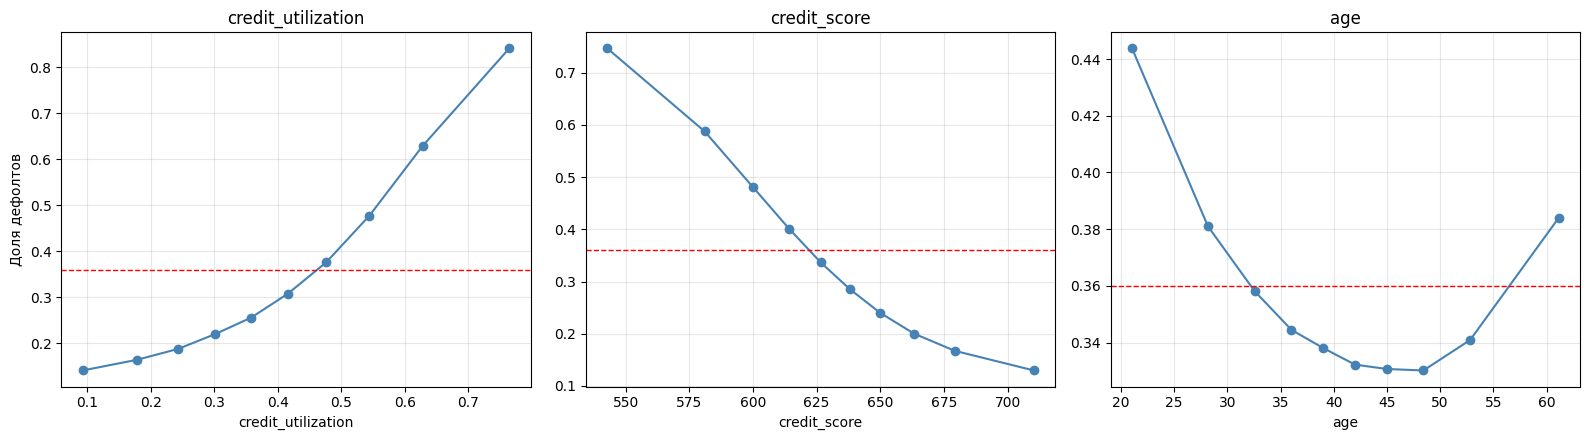

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col in zip(axes, ["credit_utilization", "credit_score", "age"]):
    b = pd.qcut(clean[col], 10, duplicates="drop")
    g = clean.groupby(b, observed=True).agg(x=(col, "mean"), dr=(TARGET, "mean"))
    ax.plot(g["x"], g["dr"], "o-", color="steelblue")
    ax.axhline(base, color="red", linestyle="--", linewidth=1)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.grid(alpha=0.3)
axes[0].set_ylabel("Доля дефолтов")
plt.tight_layout()
plt.show()

Красная линия это доля дефолтов по всей выборке. Относительно неё сразу видно, где клиент безопаснее среднего, а где опаснее. У credit_utilization кривая растёт и пересекает уровень дефолтов около 0.45, у credit_score падает и пересекает его около 620 баллов, а у age линия сначала идёт вниз, ложится и идет по дну графика в районе 45-50 лет, а потом снова идет вверх после 50 лет, то есть даёт U-образную форму. Эти графики тоже полезны в выборе модели.

**6. Границы возможного результата**

Прежде чем строить модель, стоит посмотреть на границы. Это поможет понять, а сколько можно потерять и сколько максимум заработать на этих данных. И в дальнейшем можно будет  понимать, хорош ли результат модели или нет. client_profit это финансовый результат по клиенту, если кредит выдан, то 18 % лимита, при условии что вернул или - 75 %, когда дефолт. Отказ в сумму не входит.

А ещё просмотр границ поможет узнать какой % составляют более 80 млн прибыли, которую нужно получить, так как я хочу побороться за максимум за ДЗ :D

In [12]:
OOT_size = 100_000

def client_profit(limit, target):

    return np.where(target == 0, PROFIT_NONDF * limit, -LOSS_DF * limit)

profit_if_approved = client_profit(df["desired_credit_limit"], df[TARGET])

scale = OOT_size / len(df)

profit_all = profit_if_approved.sum() * scale
profit_perfect = profit_if_approved[profit_if_approved > 0].sum() * scale
approve_rate_perfect = (profit_if_approved > 0).mean()

print(f"Если выдать всем, то у нас будет:{profit_all/1e6:>8.1f} млн")
print(f"А если не выдавать никому:{0.0:>8.1f} млн")
print(f"Грубо говоря идеальный отбор:{profit_perfect/1e6:>8.1f} млн (одобрили {approve_rate_perfect:.1%})")
print(f"\nПорог в 80 млн это {80e6/profit_perfect:.1%} от идеального отбора, который хочу превысить")

Если выдать всем, то у нас будет:  -433.7 млн
А если не выдавать никому:     0.0 млн
Грубо говоря идеальный отбор:   334.1 млн (одобрили 64.0%)

Порог в 80 млн это 23.9% от идеального отбора, который хочу превысить


Здесь я строю коридор, и по нему видно, что если выдать всем клиентам, то банк уйдёт в - 433.7 миллиона, т.е. портфель убыточен сам по себе. Верхняя граница составляет 334 миллиона. Столько мог бы получить тот, кто заранее знает, кто вернёт кредит. И выдавать нужно только этим 64 % клиентов. К сожалению, такое спрогнозировать невозможно. А 80 миллионов + это 23.9 % от идеала.



Пожалуй, EDA был наиболее объёмным разделом, поскольку это подготовка данных. Следующие будут меньше.

# Препроцессинг

Сейчас хочу собрать уже подготовленные данные в функцию, чтобы обучение и инференс на OOT.csv проходили одинаковую обработку. Функция будет работать по фиксированным константам, потому что нужно, чтобы её результат не зависел от того, какой файл в неё подан. Аномальные значения стираю в NaN, не заполняю. Градиентный бустинг на решающих деревьях обрабатывает пропуски сам. Сама по себе одстановка чего-либо на место пропуска убирает информацио том, что значение нам неизвестно.

In [13]:
cat_s = {
    "education": ["None", "HighSchool", "Bachelor", "Master", "PhD"],
    "gender": ["Female", "Male"],
    "employment_status": ["Employed", "Retired", "Self-Employed", "Unemployed"],
    "marital_status": ["Divorced", "Married", "Single", "Widowed"],
    "home_ownership": ["Mortgage", "Own", "Rent"],
    "region": ["Rural", "Suburban", "Urban"],
}

data_features = list(valid_value) + list(cat_s)

def preprocess(data):
    X = data.copy()
    for column, (lo, hi) in valid_value.items():
        X.loc[(X[column] < lo) | (X[column] > hi), column] = np.nan
    for column, levels in cat_s.items():
        X[column] = pd.Categorical(X[column], categories=levels)
    return X[data_features]

X = preprocess(df)
y = df[TARGET]

print("Размер после препроцессинга:", X.shape)
print(f"Фичей: {X.shape[1]} (столько числовых {len(valid_value)}, и столько категориальных {len(cat_s)})")
print()

na_bef = (df[data_features].isna().mean() * 100).round(2)
na_after = (X.isna().mean() * 100).round(2)
print(pd.DataFrame({"было %": na_bef, "стало %": na_after,
                    "Всего добавилось в п.п.": (na_after - na_bef).round(2)}).to_string())

Размер после препроцессинга: (1000000, 18)
Фичей: 18 (столько числовых 12, и столько категориальных 6)

                       было %  стало %  Всего добавилось в п.п.
age                      0.47     1.04                     0.57
income                   0.48     1.87                     1.39
years_employed           0.00     0.00                     0.00
credit_history_length    0.48     1.03                     0.55
num_credit_lines         0.00     0.83                     0.83
num_past_defaults        0.00     0.00                     0.00
dti_ratio                0.48     1.31                     0.83
credit_utilization       0.00     0.55                     0.55
existing_loan_amount     0.00     1.39                     1.39
credit_score             0.48     1.05                     0.57
desired_credit_limit     0.00     0.00                     0.00
num_dependents           0.00     0.00                     0.00
education                0.46     0.46                     0.00


Здесь я фиксирую категориальные фичи, не просто беру из данных, а то на OOT порядок или состав категорий может отличаться. Это опасно тем, что модель получит не ту фичу, на которой училась. 

В признаки попадают 18 из 20. Не беру client_id, так как фича без предсказательной силы, а таргет убираю в y. По таблице видно, какие изменения случились с пропусками. Например, там, где я стёрла аномальные значения, их доля выросла. Сильнее всегоэто произошло  у income и existing_loan_amount. (С 0 и половины % до 1.87 и 1.39). Хотя максимум меньше 2 % данных, то есть потеря невелика. Заполнять NaN я не буду ни средним, ни самым типичным значением, так как в дальнейшем буду использовать LightGBM. Он умеет работать с пропусками нативно и на каждом разбиении дерева сам решает, куда их отправить. К тому же, если просто подставить то же среднее, то сотрётся информация о том, что в конкретных местах эти данные мне неизвестны, а это может быть полезной информацией, которую стоит оставить как она уже есть в данных.

# Обучаю модель

ШАГ 1. Делю данные на 3 части. Как обычно на train, validation и test. Тестовую часть будет 100 000, потому что так будет в файле OOT.csv. Оценка прибыли будет считаться в одинаковом масштабе.

Лимиты (desired_credit_limit) здесь для расчета прибыли.  early_stopping сам подберет нужное число деревьев. А обучение прекратится, когда AUC на валидации больше не будет расти. Беру 100 итераций. Беру градиентный бустинг, так как он справится с нелинейной формой фичей. Разбиение делаю со stratify по таргету, чтобы доля дефолтов (36 %) была одинаковой во всех 3 частях, и чтобы оценка не поехала в случае перекоса данных.

In [14]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

X = preprocess(df)
y = df[TARGET]
limit = df["desired_credit_limit"]

X_tr, X_hold, y_tr, y_hold, lim_tr, lim_hold = train_test_split(
    X, y, limit, test_size=200_000, random_state=RANDOM_STATE, stratify=y)
X_val, X_test, y_val, y_test, lim_val, lim_test = train_test_split(
    X_hold, y_hold, lim_hold, test_size=100_000, random_state=RANDOM_STATE, stratify=y_hold)

print(f"train {X_tr.shape[0]}, valid {X_val.shape[0]}, test {X_test.shape[0]}")

model = lgb.LGBMClassifier(n_estimators=3000, learning_rate=0.05, num_leaves=63,
                           min_child_samples=100, subsample=0.8, subsample_freq=1,
                           colsample_bytree=0.8, random_state=RANDOM_STATE, verbose=-1)
model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], eval_metric="auc",
          callbacks=[lgb.early_stopping(100, verbose=False)])

print("Деревьев после early stopping:", model.best_iteration_)
print(f"ROC AUC на валидации:{roc_auc_score(y_val, model.predict_proba(X_val)[:, 1]):.4f}")
print(f"ROC AUC на тесте:{roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]):.4f}")

train 800000, valid 100000, test 100000
Деревьев после early stopping: 200
ROC AUC на валидации:0.8378
ROC AUC на тесте:0.8387


Как видно, early_stopping подобрал 200 деревьев, значит после этого количества качество на валидации перестало расти. ROC AUC на тесте = 0.8387, это очень близко с результатом на валидации = 0.8378. Делаю вывод, что переобучения нет и модель хорошо работает на данных, которых не видела.

ШАГ 2. Проверяю насколько моя модель адекватная.

Хочу проверить, что модель опирается на осмысленные признаки, а не на какой-нибудь шум. Сравниваю её собственную оценку важности с тем, что я делала в EDA. И если вверху будут признаки с около 0-ым IV, значит что-то тут не так.

In [15]:
imp = pd.DataFrame({"feature": data_features, "importance": model.feature_importances_})
imp["доля %"] = (imp.importance / imp.importance.sum() * 100).round(2)
print(imp.sort_values("importance", ascending=False).to_string(index=False))

              feature  importance  доля %
                  age        1734   13.98
            dti_ratio        1586   12.79
   credit_utilization        1545   12.46
         credit_score        1366   11.02
            education        1224    9.87
               income         819    6.60
    employment_status         750    6.05
credit_history_length         683    5.51
 existing_loan_amount         585    4.72
 desired_credit_limit         556    4.48
    num_past_defaults         516    4.16
       years_employed         482    3.89
     num_credit_lines         162    1.31
       num_dependents         130    1.05
       home_ownership          83    0.67
               region          78    0.63
       marital_status          68    0.55
               gender          33    0.27


Можно заметить, что наверху dti_ratio, credit_utilization, credit_score и education. А это те фичи, которые с самым высоким IV. Тогда как внизу gender, marital_status, region и home_ownership. Как раз их IV был около 0-ой. Модель тратит на них < 1 % расщеплений каждый. 

Отдельно хочу прокомментировать age. Эта фича вышла на первую строку, хотя по IV она была ранее 7-ой. Это можно объяснить необычной U-образной формой этой фичи, так как чтобы описать кривую с разворотом, дереву нужно много разрезов. А, к примеру, credit_utilization описывается меньшим числом разрезов при большей пользе от каждого. Более того, num_past_defaults ушел примерно в середину. Раньше он был на 3-ем месте с IV = 0.2582, сейчас он в таблице важности 11 из 18. num_past_defaults принимает всего 7 значений (от 0 до 6), поэтому 1 разреза по нему может быть достаточно. Можно сделать вывод, что метрика feature_importances показывает, сколько раз фича использовалась, а не сколько пользы она принесла. И по этой причине на неё следует смотреть вместе с IV, а не вместо него.

# Калибровка и подбор порога

ШАГ 1. Проверка калибровки.

Решение об одобрении кредита будет приниматься путём сравнения предсказанной вероятности с абсолютным порогом, который я нашла ранее = 0.19355. Здесь буду делить клиентов на бины по предсказанному риску и сравнивать средний прогноз с фактической долей дефолтов внутри бина. И если модель откалибрована, в каждом бине предсказанная вероятность должна почти совпасть с фактической долей дефолтов.

In [16]:
p_test = model.predict_proba(X_test)[:, 1]

b = pd.qcut(p_test, 10, labels=False)
calib = pd.DataFrame({"pred": p_test, "fact": y_test.values, "bin": b}).groupby("bin").agg(
    n=("fact", "size"), pred_PD=("pred", "mean"), fact_PD=("fact", "mean"))
calib["Разница"] = (calib.pred_PD - calib.fact_PD).round(4)
calib["Ст.ошибка"] = np.sqrt(calib.fact_PD * (1 - calib.fact_PD) / calib.n)
calib["z"] = (calib["Разница"] / calib["Ст.ошибка"]).round(2)
print(calib.round(4).to_string())

         n  pred_PD  fact_PD  Разница  Ст.ошибка     z
bin                                                   
0    10000   0.0721   0.0764  -0.0043     0.0027 -1.62
1    10000   0.0937   0.0994  -0.0057     0.0030 -1.91
2    10000   0.1175   0.1205  -0.0030     0.0033 -0.92
3    10000   0.1508   0.1497   0.0011     0.0036  0.31
4    10000   0.2020   0.1898   0.0122     0.0039  3.11
5    10000   0.2843   0.2711   0.0132     0.0044  2.97
6    10000   0.4154   0.4058   0.0096     0.0049  1.96
7    10000   0.5921   0.6006  -0.0085     0.0049 -1.74
8    10000   0.7735   0.7885  -0.0150     0.0041 -3.67
9    10000   0.9030   0.8965   0.0065     0.0030  2.13


Модель откалибрована хорошо. Предсказанная вероятность и фактическая доля дефолтов почти полностью совпадают во всех десяти бинах. Максимальное расхождение всего 1.5 п.п. А это очень важно, так как мы сравниваем прогноз с фиксированным порогом = 0.19355. Если посмотреть на бин 4 и 5, примерно там и проходит наш порог. И там расхождение максимальное 0.0122 и 0.0132, значит модель слегка завышает риск.

Дополняю графиком для наглядности. 

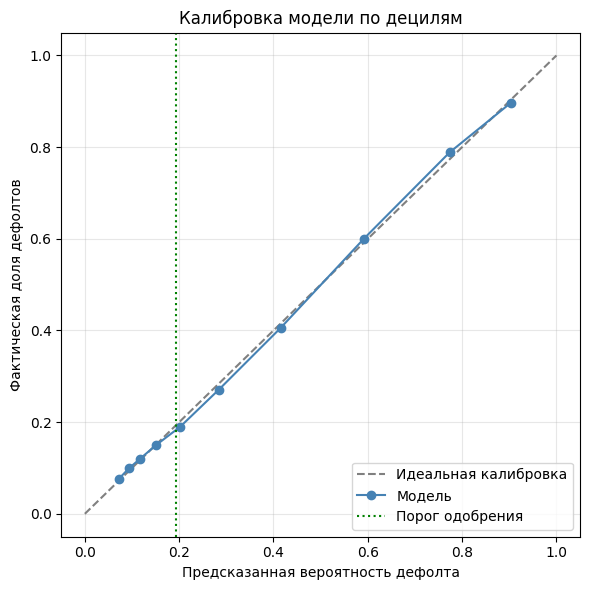

In [17]:
plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Идеальная калибровка")
plt.plot(calib.pred_PD, calib.fact_PD, "o-", color="steelblue", label="Модель")
plt.axvline(PD_THRESHOLD, color="green", linestyle=":", label="Порог одобрения")
plt.xlabel("Предсказанная вероятность дефолта")
plt.ylabel("Фактическая доля дефолтов")
plt.title("Калибровка модели по децилям")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Чем ближе точки к диагонали, тем честнее модель оценивает вероятности. А каждая точка это и есть дециль. По горизонтали средний прогноз, по вертикали фактическая доля дефолтов. Если модель идеально откалибрована, то она ложится точно на диагональ. В моём же случае точки лежат очень-очень близко,ипочти ровно на диагонали по всему диапазону. Это говорит о том, что модель выдаёт правильные вероятности, не просто ранжирует клиентов. А если бы, например, было бы завышение риска, то модель заставила бы отказаться от прибыльных клиентов. Зелёная линия обозначает порог. Точка лежит там чуть ниже диагонали. Это означает, что фактических дефолтов меньше, чем предсказанных и модель немного перестраховывается (это ещё до графика чисто по данным определила). К слову, этим же объясняется сдвиг эмпирического оптимума порога вправо относительно того, что выведен аналитически.

ШАГ 2. Подбор порога по прибыли и оценка устойчивости.

Теперь перебираю пороги и смотрю, при каком прибыль максимальна. Потом сравню его с выведенным порогом = 0.19355. Дополнительно прогоняю бутстрап, чтобы понять какой разброс прибыли. И чтобы перестраховаться, что есть запас более 80 миллионов) Бутстрап нужен потому, что я не знаю распределение той выборке, на которой потом прогонят мою модель.Он нужен, чтобы понять, насколько результат устойчив. И результат соответственно будет другим. Беру перцентили от 5 до 95, чтобы охватить 90-процентный интервал.

In [18]:
def profit_at(mask):
    return np.where(y_test.values[mask] == 0,
                    PROFIT_NONDF * lim_test.values[mask],
                    -LOSS_DF * lim_test.values[mask]).sum()

grid = np.arange(0.05, 0.45, 0.005)
res = [(t, profit_at(p_test < t)) for t in grid]
best_t, best_v = max(res, key=lambda r: r[1])

print(f"Выведенный порог {PD_THRESHOLD:.5f}: {profit_at(p_test < PD_THRESHOLD)/1e6:8.1f} млн, "
      f"Одобрено {(p_test < PD_THRESHOLD).mean():.1%}")
print(f"Лучший порог {best_t:.5f}: {best_v/1e6:8.1f} млн, одобрено {(p_test < best_t).mean():.1%}")
print()
for t in [0.15, 0.17, 0.19355, 0.21, 0.23, 0.25]:
    print(f"Порог {t:.5f}: {profit_at(p_test < t)/1e6:8.1f} млн, одобрено {(p_test < t).mean():5.1%}")


rng = np.random.default_rng(RANDOM_STATE)
boot = []
for i in range(300):
    idx = rng.integers(0, len(p_test), len(p_test))
    pp, yy, ll = p_test[idx], y_test.values[idx], lim_test.values[idx]
    m = pp < PD_THRESHOLD
    boot.append(np.where(yy[m] == 0, PROFIT_NONDF * ll[m], -LOSS_DF * ll[m]).sum())
boot = np.array(boot) / 1e6

print(f"\nПо бутстрапу прибыль:")
print(f"Среднее {boot.mean():.1f} млн, стандартное отклонение {boot.std():.1f} млн")
print(f"5-й перцентиль = {np.percentile(boot, 5):.1f} млн, 95-й перцентиль = {np.percentile(boot, 95):.1f} млн")
print(f"Сколько раз прибыль была ниже 80 млн: {(boot < 80).mean():.1%}")
print(f"Минимум по всем интерациям = {boot.min():.1f} млн, максимум = {boot.max():.1f} млн")

FINAL_THRESHOLD = PD_THRESHOLD  

Выведенный порог 0.19355:     91.4 млн, Одобрено 43.8%
Лучший порог 0.20500:     91.9 млн, одобрено 45.6%

Порог 0.15000:     84.9 млн, одобрено 35.0%
Порог 0.17000:     89.0 млн, одобрено 39.5%
Порог 0.19355:     91.4 млн, одобрено 43.8%
Порог 0.21000:     91.6 млн, одобрено 46.4%
Порог 0.23000:     91.0 млн, одобрено 49.2%
Порог 0.25000:     88.8 млн, одобрено 51.6%

По бутстрапу прибыль:
Среднее 91.3 млн, стандартное отклонение 2.5 млн
5-й перцентиль = 87.4 млн, 95-й перцентиль = 95.2 млн
Сколько раз прибыль была ниже 80 млн: 0.0%
Минимум по всем интерациям = 84.5 млн, максимум = 98.5 млн


Здесь из интересного boot.mean(), это средняя прибыль по всем повторам, а boot.std() показывает типичное отклонение от неё. Ставлю 300 интераций, чтобы было достаточно.

Выведенный порог = 0.19355 дал 91.4 млн, а эмпирический = 0.205, и он дал 91.9 млн прибыли. Фактически 2 независимо полученных числа почти совпали. Это подтверждает, что формула и калибровка модели верные. А разница 0.5 млн лежит в пределах шума. Это видно по таблице порогов. Также можно заметить, что на всём участке от 0.19355 до 0.23000 прибыль находится около 91 млн, то есть меняется слабо. Думаю, поэтому могу взять в качестве  финального трешхолда выведенный ранее 0.19355. Так можно снизить риск переобучения. К слову, бутстрап показывает, что средняя прибыль = 91.3 млн при стандартном отклонении 2.5 млн. А 5-ый перцентиль = 87.4, в то время как 95-ый = 95.2. Получается, что только в 5 случаях из 100 прибыль падала ниже 87.4 млн. И только в 5 росла выше 95.2 млн. Более того, очень хороший знак, что за все 300 интераций, прибыль не опустилась ниже 80 млн.

Строю кривую прибыли по всем перебранным порогам, чтобы увидеть, где я нахожусь относительно оптимума и относительно желаемого превышения в 80 миллионов.

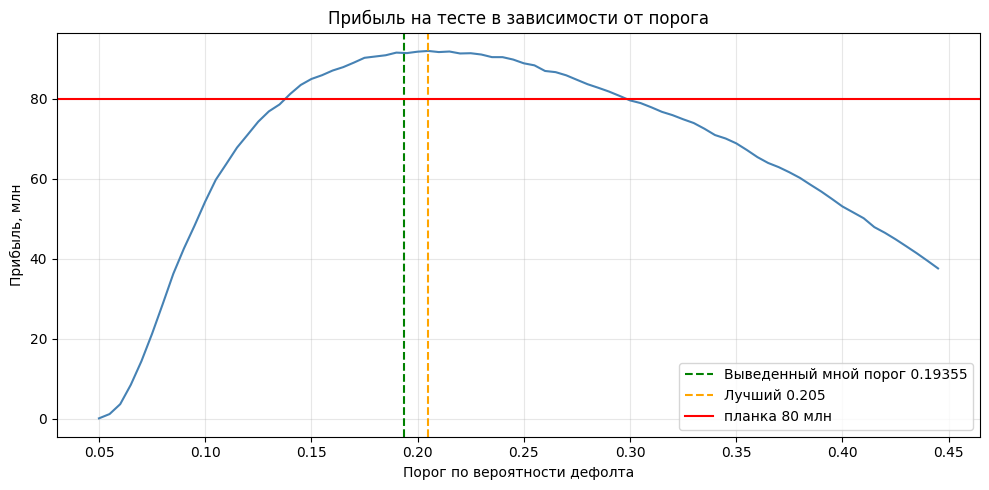

In [19]:
profits = np.array([v for _, v in res]) / 1e6

plt.figure(figsize=(10, 5))
plt.plot(grid, profits, color="steelblue")
plt.axvline(PD_THRESHOLD, color="green", linestyle="--", label=f"Выведенный мной порог {PD_THRESHOLD:.5f}")
plt.axvline(best_t, color="orange", linestyle="--", label=f"Лучший {best_t:.3f}")
plt.axhline(80, color="red", linewidth=1.5, label="планка 80 млн")
plt.xlabel("Порог по вероятности дефолта")
plt.ylabel("Прибыль, млн")
plt.title("Прибыль на тесте в зависимости от порога")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

График всегда лучше объясняет данные, так как это визуальное восприятие. Как видно, на кривой отмечены оба порога, выведенный аналитическим способом 0.19355 и найденный перебором 0.205 (эмпирически). Они лежат посередине и очень близко друг к другу. В целом, не так важно какой из них выбрать, на деньги это почти не повлияет (91.4 или 91.9 млн). Прибыдь > 80 млн прослеживается на всём участке (примерно от 0.13 до 0.30). Значит попасть выше неё реально. Этот график, пожалуй, главный для нашего кейса. Он оценивают именно деньги.

И ещё интересно посмотреть распределение прибыли. Строю гистограмму и смотрю на плохой хвост прибыли.

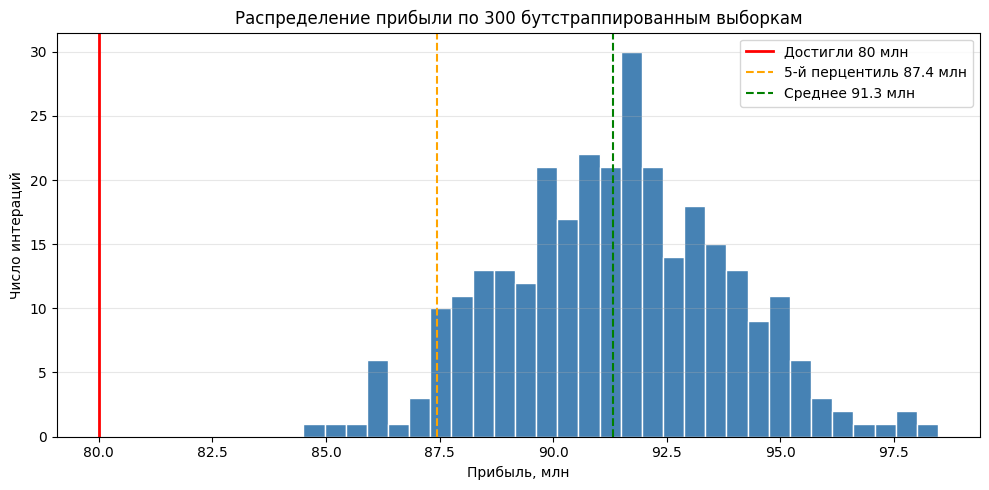

In [20]:
plt.figure(figsize=(10, 5))
plt.hist(boot, bins=30, color="steelblue", edgecolor="white")
plt.axvline(80, color="red", linewidth=2, label="Достигли 80 млн")
plt.axvline(np.percentile(boot, 5), color="orange", linestyle="--",
            label=f"5-й перцентиль {np.percentile(boot, 5):.1f} млн")
plt.axvline(boot.mean(), color="green", linestyle="--", label=f"Среднее {boot.mean():.1f} млн")
plt.xlabel("Прибыль, млн")
plt.ylabel("Число интераций")
plt.title("Распределение прибыли по 300 бутстраппированным выборкам")
plt.legend()
plt.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

По графику четко видно, что распределение лежит правее красной линии, тех самых 80 млн. Разброс значений примерно в диапазоне от 84 до 98 млн. Обозначен 5-ый перцентиль = 87.4 и среднее значение = 91.3 млн. Этот график полезен тем, что показывает, что результат должен получится выше 80 млн. А минимальный из исходов = 84.5 млн (это до графика, где я выводила минимум и максимум).

# Инференс

ШАГ 1. Сейчас хочу сделать проверку. Собираю файл из своего отложенного теста, чтобы убедиться, что пайплайн отрабатывает на файле целиком, а не только на подготовленных данных. В этом же месте разделяю, чтобы ничего не сломалось, когда уже есть файл (ну и сейчас у меня OOT.csv) и когда его нужно будет симитировать для самопроверке, если вдруг его не будет рядом.

In [21]:
import os

if os.path.exists(OOT_path):
    print("Найден", OOT_path, "работаем тут")
else:
    df.loc[X_test.index].to_csv(OOT_path, index=False)
    print("Файл для самопроверки:", OOT_path)

Найден OOT.csv работаем тут


ШАГ 2. Проверки для уверенности в модели.

Здесь хочу проверить, что файл выглядит так же, как обучающие данные. Если бутстрап предсказал статистически значимые риски, то здесь хочу отловить расхождения в структуре и обработке данных, из-за которых модель может отработать, но даст неверный результат.

Как рассказали на лекции по мл систем дизайну, PSI сравнивает два распределения и показывает, насколько сильно они разошлись. И этот сдвиг вполне можно померить. До 0.1 сдвига нет, от 0.1 до 0.25 сдвиг умеренный, а выше 0.25 существенный. Был пример, как  PSI ловил дрейф данных во времени, здесь же я применяю его к трейну и OOT, чтобы убедиться, что предсказаниям возможно адекватно сделать.

In [22]:
def psi(expected, actual, bins=10):
    edges = np.quantile(expected, np.linspace(0, 1, bins + 1))
    edges[0], edges[-1] = -np.inf, np.inf
    e = np.histogram(expected, bins=edges)[0] / len(expected)
    a = np.histogram(actual, bins=edges)[0] / len(actual)
    e, a = np.clip(e, 1e-6, None), np.clip(a, 1e-6, None)
    return float(((a - e) * np.log(a / e)).sum())

oot_gap = load_data(OOT_path)
print("Строк в OOT:", len(oot_gap))

missing = [c for c in data_features if c not in oot_gap.columns]
print("Каких колонок нет:", missing if missing else "Все колонки есть")

X_oot = preprocess(oot_gap)

control_data = pd.DataFrame({"train %": (X.isna().mean() * 100).round(2),
                         "OOT %": (X_oot.isna().mean() * 100).round(2)})
control_data["Разница"] = (control_data["OOT %"] - control_data["train %"]).round(2)
print()
print(control_data.to_string())

p_oot = model.predict_proba(X_oot)[:, 1]
print()
print(f"PSI по предсказанной вероятности: {psi(p_test, p_oot):.4f}")
for c in ["credit_utilization", "credit_score", "age", "dti_ratio"]:
    print(f"PSI по {c}: {psi(X_test[c].dropna(), X_oot[c].dropna()):.4f}")
print()
print(f"Среднее PD на тесте {p_test.mean():.4f}, и на OOT {p_oot.mean():.4f}")

Строк в OOT: 100000
Каких колонок нет: Все колонки есть

                       train %  OOT %  Разница
age                       1.04   1.06     0.02
income                    1.87   1.83    -0.04
years_employed            0.00   0.00     0.00
credit_history_length     1.03   1.01    -0.02
num_credit_lines          0.83   0.77    -0.06
num_past_defaults         0.00   0.00     0.00
dti_ratio                 1.31   1.36     0.05
credit_utilization        0.55   0.62     0.07
existing_loan_amount      1.39   1.38    -0.01
credit_score              1.05   1.10     0.05
desired_credit_limit      0.00   0.00     0.00
num_dependents            0.00   0.00     0.00
education                 0.46   0.46     0.00
gender                    0.00   0.00     0.00
employment_status         0.48   0.47    -0.01
marital_status            0.00   0.00     0.00
home_ownership            0.00   0.00     0.00
region                    0.00   0.00     0.00

PSI по предсказанной вероятности: 0.0000
PSI по c

Исходя из результата можно сказать, что все 3 проверки выполнились успешно. 1) Проверка колонок с фичами (missing = [c for c in data_features if c not in oot_gap.columns]). 18 фич на месте и никакие колонки не потерялись. Это говорит мне о том, что структура данных совпадает с ожидаемой. 2) Доля пропусков после препроцессинга (control_data). Она почти равна трейну. Максимальное расхождение у credit_utilization 0.07 п.п. (0.55 и 0.62). А как видно для education ровно 0.46 и там, и там. Это тоже хорошо, значит категория None опознается именно как категория, а не пропуск. 3) PSI по предсказанной вероятности и по 4 основным фичам, и сравнение среднего PD. PSI = 0 при пороге в 0.1. (Хотя я понимаю, что на скрытом тесте числа точно будут отличны от 0. Здесь же ООТ был из известных данных, из отложенной части). Средняя вероятность дефолта (PD) = 0.3604 на тесте и столько же на OOT. Соответственно, модель видит обе выборки одинаково.

ШАГ 3. Итоговое решение.

Уже на финишной прямой применяю порог к предсказанным вероятностям и готовлю датафрейм. Возвращаясь к изначальной постановке кейса, одобряем клиента, если предсказанная вероятность дефолта у него ниже выведенного порога = 0.19355.

In [23]:
appr_good = (p_oot < FINAL_THRESHOLD).astype(int)

result = oot_gap.copy()
result["approved"] = appr_good

print(f"Порог одобрения: {FINAL_THRESHOLD:.5f}")
print(f"Одобрено {appr_good.mean():.1%} клиентам ({appr_good.sum()} а всего их {len(appr_good)})")
print()
print(result[["client_id", "desired_credit_limit", "approved"]].head().to_string(index=False))
print()
print("Итоговый датафрейм:", result.shape)

Порог одобрения: 0.19355
Одобрено 43.8% клиентам (43836 а всего их 100000)

 client_id  desired_credit_limit  approved
    934705              69951.05         1
    951912              26177.72         1
    105606              18925.39         0
    814266              18628.82         0
    830234              40442.04         1

Итоговый датафрейм: (100000, 21)


Финальный датафрейм содержит все колонки исходного файла и ещё колонка approved, фича с флагом 1 для одобренных клиентов и 0 для тех, кому откажем. Всего одобрено 43.8 % заявок. Меньше половины (т.е. < 50 000). И это объяснимо, так как убыток от дефолта более чем в 4 раза тяжелее прибыли от хорошего клиента (Это было дано ещё в условии, 18 % и 75 %). Порог я беру = 0.19355, выведенный из условия кейса до моделирования. Эмпирический = 0.205, найденный перебором по тесту не беру. Разница между ними была небольшая, но подгонка под конкретные 100 тыс. наблюдений повышает риск переобучения. На созданной мной OOT максимизировать совокупную чистую прибыль по всем клиентам получилось до 91.4 млн. Получившийся результат согласуется с оценкой на тесте и с интервалом, найденным бутстрапом. Делаю вывод, что мой пайплайн отрабатывает и воспроизводится.

Спасибо огромное за столь креативное ДЗ! Честно, оно и челенджевое, и при этом самое интересное из всех, что были, потому здесь полностью творчество на мне! 

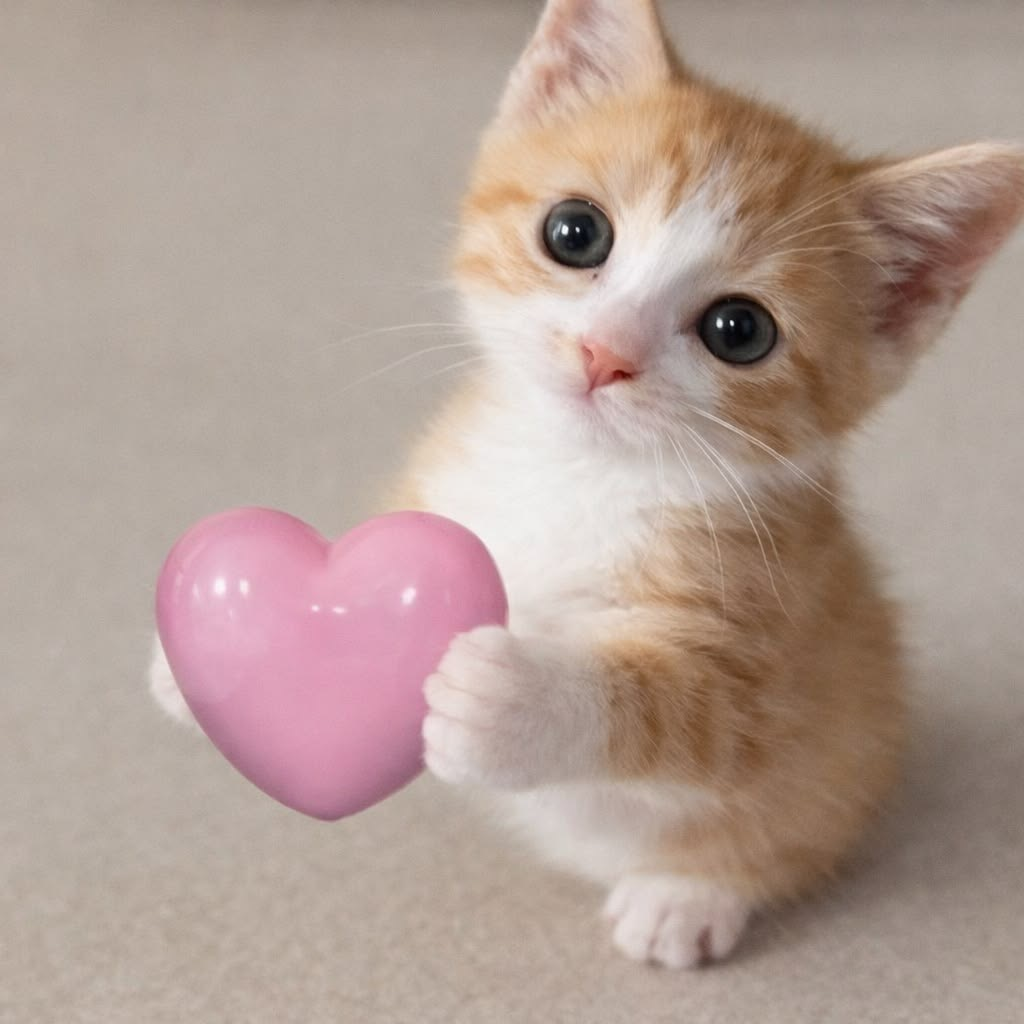

In [24]:
from IPython.display import Image, display

display(Image(filename="IMG_5061.JPG"))